# Implementação de Variational Autoencoder (VAE) no Fashion MNIST

**Disciplina:** Artificial Neural Networks and Deep Learning  
**Projeto:** VAE Implementation  
**Dataset:** Fashion MNIST

---

## Introdução

Este projeto implementa e avalia uma **Variational Autoencoder (VAE)**. 
O modelo é aplicado ao dataset Fashion MNIST, que contém 70.000 imagens em escala de cinza (28×28 pixels) de 10 categorias de roupas e acessórios.

### Objetivos do Projeto

1. Implementar uma VAE completa com encoder, decoder e reparameterization trick
2. Treinar o modelo no dataset Fashion MNIST
3. Avaliar a qualidade das reconstruções
4. Explorar o espaço latente aprendido através de visualizações
5. Gerar novas amostras sintéticas a partir do espaço latente
6. Comparar VAE com um Autoencoder tradicional (AE)

## 1. Importação de Bibliotecas

Importamos todas as bibliotecas necessárias para a implementação:
- PyTorch para construção e treinamento do modelo
- Torchvision para carregar o dataset Fashion MNIST
- Matplotlib e Seaborn para visualizações
- NumPy para operações numéricas
- Scikit-learn para redução dimensional (t-SNE/PCA)

In [35]:
# Bibliotecas principais
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Dataset e transformações
from torchvision import datasets, transforms

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Redução dimensional para visualização do latent space
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Utilitários
from tqdm import tqdm
import os

# Configurações de visualização
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Configurar device (CPU ou GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando device: {device}')

# Seed para reprodutibilidade
torch.manual_seed(42)
np.random.seed(42)

Usando device: cpu


## 2. Preparação dos Dados

### 2.1 Carregamento do Dataset

Utilizamos o Fashion MNIST, que contém 70.000 imagens em escala de cinza (28x28) de 10 categorias de roupas.
As imagens são normalizadas para o intervalo [0, 1] e transformadas em tensores.

In [36]:
# Transformações: converter para tensor e normalizar para [0, 1]
transform = transforms.Compose([
    transforms.ToTensor(),  # Converte PIL Image para tensor e normaliza [0, 255] -> [0, 1]
])

# Carregar dataset completo
full_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Dataset de teste
test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Classes do Fashion MNIST
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f'Total de imagens no conjunto de treinamento: {len(full_dataset)}')
print(f'Total de imagens no conjunto de teste: {len(test_dataset)}')
print(f'Formato das imagens: {full_dataset[0][0].shape}')

Total de imagens no conjunto de treinamento: 60000
Total de imagens no conjunto de teste: 10000
Formato das imagens: torch.Size([1, 28, 28])


### 2.2 Divisão em Treino e Validação

Dividimos o conjunto de treinamento em 80% para treino e 20% para validação.

In [37]:
# Definir tamanhos dos conjuntos
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Dividir dataset
train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f'Tamanho do conjunto de treinamento: {len(train_dataset)}')
print(f'Tamanho do conjunto de validação: {len(val_dataset)}')

Tamanho do conjunto de treinamento: 48000
Tamanho do conjunto de validação: 12000


### 2.3 DataLoaders

Criamos DataLoaders para carregar os dados em batches durante o treinamento.

In [38]:
# Hiperparâmetros
batch_size = 128

# Criar DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f'Número de batches de treinamento: {len(train_loader)}')
print(f'Número de batches de validação: {len(val_loader)}')
print(f'Número de batches de teste: {len(test_loader)}')

Número de batches de treinamento: 375
Número de batches de validação: 94
Número de batches de teste: 79


### 2.4 Visualização de Amostras do Dataset

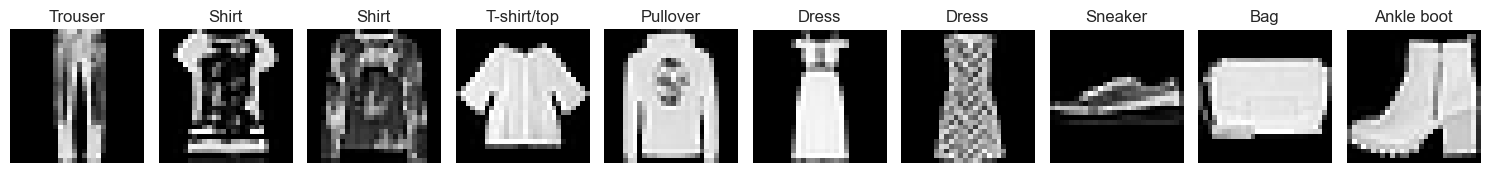

In [39]:
# Visualizar algumas amostras do dataset
def visualize_samples(dataset, n_samples=10):
    """
    Visualiza n_samples imagens do dataset.
    
    Args:
        dataset: Dataset do PyTorch
        n_samples: Número de amostras a visualizar
    """
    fig, axes = plt.subplots(1, n_samples, figsize=(15, 2))
    
    for i in range(n_samples):
        idx = np.random.randint(0, len(dataset))
        img, label = dataset[idx]
        
        # Converter tensor para numpy e remover dimensão de canal
        img_np = img.squeeze().numpy()
        
        axes[i].imshow(img_np, cmap='gray')
        axes[i].set_title(classes[label])
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_samples(full_dataset, n_samples=10)

---

## 2.5 Fundamentação Teórica

### 2.5.1 Autoencoders Tradicionais

Autoencoders são redes neurais projetadas para aprender representações comprimidas de dados através de dois componentes:

- **Encoder (E)**: Mapeia a entrada **x** para uma representação latente **z** de menor dimensão: `z = E(x)`
- **Decoder (D)**: Reconstrói a entrada original a partir de **z**: `x̂ = D(z)`

O objetivo é minimizar a diferença entre **x** e **x̂**, forçando o modelo a capturar as características mais importantes dos dados.

### 2.5.2 Variational Autoencoders (VAEs)

VAEs estendem autoencoders ao introduzir uma abordagem probabilística:

1. **Encoder**: Em vez de mapear **x** diretamente para **z**, o encoder mapeia **x** para os **parâmetros de uma distribuição** sobre **z**: `q(z|x) ~ N(μ, σ²)`
   - μ: média da distribuição latente
   - σ²: variância da distribuição latente

2. **Reparameterization Trick**: Para permitir backpropagation através da operação estocástica de amostragem, expressamos **z** como:
   ```
   z = μ + σ ⊙ ε,  onde ε ~ N(0, I)
   ```
   Esta formulação torna a amostragem diferenciável com relação a μ e σ.

3. **Decoder**: Reconstrói **x** a partir de **z** amostrado: `p(x|z)`

### 2.5.3 Função de Perda da VAE

A função de perda combina dois termos:

```
L = Reconstruction Loss + β × KL Divergence
```

**1. Reconstruction Loss (Binary Cross-Entropy):**  
Mede quão bem o decoder reconstrói a entrada original.

```
L_recon = -E[log p(x|z)]
```

**2. KL Divergence:**  
Regulariza o espaço latente para seguir uma distribuição normal padrão N(0, I), garantindo continuidade e estruturação.

```
L_KL = KL(q(z|x) || p(z)) = -0.5 × Σ(1 + log(σ²) - μ² - σ²)
```

A perda total incentiva:
- **Reconstrução fiel** através de L_recon
- **Espaço latente estruturado** através de L_KL

### 2.5.4 Vantagens das VAEs

1. **Espaço Latente Contínuo**: Permite interpolação suave entre pontos
2. **Geração de Amostras**: Novas amostras podem ser geradas amostrando z ~ N(0, I)
3. **Regularização**: KL divergence previne overfitting
4. **Interpretabilidade**: Espaço latente estruturado facilita análise

## 3. Implementação do Modelo VAE

### 3.1 Arquitetura da VAE

Uma VAE consiste em três componentes principais:

1. **Encoder**: Mapeia a entrada x para os parâmetros (μ, log σ²) da distribuição latente
2. **Reparameterization Trick**: Permite amostragem diferenciável z = μ + σ * ε, onde ε ~ N(0,1)
3. **Decoder**: Reconstrói a entrada a partir da representação latente z

A função de perda combina:
- **Reconstruction Loss**: MSE entre entrada e saída reconstruída
- **KL Divergence**: Regulariza o espaço latente para seguir uma distribuição normal

In [40]:
class VAE(nn.Module):
    """
    Implementação de uma Variational Autoencoder (VAE).
    
    Arquitetura:
        Encoder: 784 -> 400 -> [latent_dim (μ), latent_dim (log σ²)]
        Decoder: latent_dim -> 400 -> 784
    """
    
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        """
        Args:
            input_dim: Dimensão da entrada (28*28=784 para MNIST)
            hidden_dim: Dimensão da camada oculta
            latent_dim: Dimensão do espaço latente
        """
        super(VAE, self).__init__()
        
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        
        # === ENCODER ===
        # Camada totalmente conectada: input -> hidden
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        
        # Camadas para gerar os parâmetros da distribuição latente
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)      # Média μ
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)  # Log variância log(σ²)
        
        # === DECODER ===
        # Camada totalmente conectada: latent -> hidden
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        
        # Camada de reconstrução: hidden -> output
        self.fc4 = nn.Linear(hidden_dim, input_dim)
    
    def encode(self, x):
        """
        Encoder: mapeia entrada x para parâmetros da distribuição latente (μ, log σ²).
        
        Args:
            x: Tensor de entrada [batch_size, input_dim]
        
        Returns:
            mu: Média da distribuição latente [batch_size, latent_dim]
            logvar: Log variância da distribuição latente [batch_size, latent_dim]
        """
        # Camada oculta com ativação ReLU
        h = F.relu(self.fc1(x))
        
        # Calcular μ e log(σ²)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        """
        Reparameterization Trick: z = μ + σ * ε, onde ε ~ N(0,1).
        
        Este truque permite backpropagation através da operação de amostragem
        ao tornar a amostragem determinística com relação aos parâmetros μ e σ.
        
        Args:
            mu: Média [batch_size, latent_dim]
            logvar: Log variância [batch_size, latent_dim]
        
        Returns:
            z: Amostra do espaço latente [batch_size, latent_dim]
        """
        # Calcular desvio padrão: σ = exp(0.5 * log(σ²))
        std = torch.exp(0.5 * logvar)
        
        # Amostrar ε de uma distribuição normal padrão
        eps = torch.randn_like(std)
        
        # z = μ + σ * ε
        z = mu + eps * std
        
        return z
    
    def decode(self, z):
        """
        Decoder: reconstrói a entrada a partir da representação latente z.
        
        Args:
            z: Representação latente [batch_size, latent_dim]
        
        Returns:
            x_recon: Entrada reconstruída [batch_size, input_dim]
        """
        # Camada oculta com ativação ReLU
        h = F.relu(self.fc3(z))
        
        # Reconstrução com sigmoid para garantir valores em [0, 1]
        x_recon = torch.sigmoid(self.fc4(h))
        
        return x_recon
    
    def forward(self, x):
        """
        Forward pass completo da VAE.
        
        Args:
            x: Entrada [batch_size, input_dim]
        
        Returns:
            x_recon: Entrada reconstruída [batch_size, input_dim]
            mu: Média da distribuição latente [batch_size, latent_dim]
            logvar: Log variância da distribuição latente [batch_size, latent_dim]
        """
        # Encode: x -> (μ, log σ²)
        mu, logvar = self.encode(x)
        
        # Reparameterize: (μ, log σ²) -> z
        z = self.reparameterize(mu, logvar)
        
        # Decode: z -> x_recon
        x_recon = self.decode(z)
        
        return x_recon, mu, logvar

# Instanciar o modelo
latent_dim = 20  # Dimensão do espaço latente
vae = VAE(input_dim=784, hidden_dim=400, latent_dim=latent_dim).to(device)

print(vae)
print(f'\nNúmero total de parâmetros: {sum(p.numel() for p in vae.parameters()):,}')

VAE(
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=20, bias=True)
  (fc3): Linear(in_features=20, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=784, bias=True)
)

Número total de parâmetros: 652,824


### 3.2 Função de Perda (Loss Function)

A função de perda da VAE é composta por dois termos:

1. **Reconstruction Loss**: Mede quão bem o decoder reconstrói a entrada. Usamos Binary Cross-Entropy (BCE).
2. **KL Divergence**: Mede a divergência entre a distribuição latente aprendida q(z|x) e a prior p(z) ~ N(0,1).

$$L = \text{BCE}(x, \hat{x}) + \beta \cdot \text{KL}(q(z|x) || p(z))$$

onde:
$$\text{KL} = -0.5 \sum_{i=1}^{d} (1 + \log(\sigma_i^2) - \mu_i^2 - \sigma_i^2)$$

In [41]:
def vae_loss(x_recon, x, mu, logvar, beta=1.0):
    """
    Calcula a função de perda da VAE.
    
    Args:
        x_recon: Entrada reconstruída [batch_size, input_dim]
        x: Entrada original [batch_size, input_dim]
        mu: Média da distribuição latente [batch_size, latent_dim]
        logvar: Log variância da distribuição latente [batch_size, latent_dim]
        beta: Peso da KL divergence (beta-VAE)
    
    Returns:
        loss: Perda total
        bce: Reconstruction loss (Binary Cross-Entropy)
        kld: KL Divergence
    """
    # Reconstruction Loss: Binary Cross-Entropy
    # BCE mede a diferença entre a entrada original e a reconstruída
    bce = F.binary_cross_entropy(x_recon, x, reduction='sum')
    
    # KL Divergence entre q(z|x) e p(z) = N(0,1)
    # KL(q(z|x) || p(z)) = -0.5 * sum(1 + log(σ²) - μ² - σ²)
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    # Perda total: BCE + β * KL
    # β controla o trade-off entre reconstrução e regularização
    loss = bce + beta * kld
    
    return loss, bce, kld

## 4. Treinamento

### 4.1 Configuração do Treinamento

In [42]:
# Hiperparâmetros de treinamento
num_epochs = 50
learning_rate = 1e-3
beta = 1.0  # Peso da KL divergence (beta-VAE)

# Otimizador Adam
optimizer = optim.Adam(vae.parameters(), lr=learning_rate)

# Scheduler para ajustar learning rate
# Nota: O argumento 'verbose' foi removido em versões recentes do PyTorch
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

print(f'Configuração de treinamento:')
print(f'  - Épocas: {num_epochs}')
print(f'  - Learning Rate: {learning_rate}')
print(f'  - Beta: {beta}')
print(f'  - Otimizador: Adam')
print(f'  - Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)')

Configuração de treinamento:
  - Épocas: 50
  - Learning Rate: 0.001
  - Beta: 1.0
  - Otimizador: Adam
  - Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)


### 4.2 Funções de Treinamento e Validação

In [43]:
def train_epoch(model, train_loader, optimizer, beta, device):
    """
    Treina o modelo por uma época.
    
    Args:
        model: Modelo VAE
        train_loader: DataLoader de treinamento
        optimizer: Otimizador
        beta: Peso da KL divergence
        device: Device (CPU ou GPU)
    
    Returns:
        avg_loss: Perda média da época
        avg_bce: BCE médio da época
        avg_kld: KLD médio da época
    """
    model.train()
    
    total_loss = 0
    total_bce = 0
    total_kld = 0
    
    # Barra de progresso
    pbar = tqdm(train_loader, desc='Treinando')

    for batch_idx, (data, _) in enumerate(pbar):
        # Mover dados para o device
        data = data.to(device)
        
        # Achatar imagens: [batch_size, 1, 28, 28] -> [batch_size, 784]
        data = data.view(-1, 784)
        
        # Zerar gradientes
        optimizer.zero_grad()
        
        # Forward pass
        x_recon, mu, logvar = model(data)
        
        # Calcular perda
        loss, bce, kld = vae_loss(x_recon, data, mu, logvar, beta)
        
        # Backward pass e otimização
        loss.backward()
        optimizer.step()
        
        # Acumular perdas
        total_loss += loss.item()
        total_bce += bce.item()
        total_kld += kld.item()
    
    # Calcular médias
    avg_loss = total_loss / len(train_loader.dataset)
    avg_bce = total_bce / len(train_loader.dataset)
    avg_kld = total_kld / len(train_loader.dataset)
    
    return avg_loss, avg_bce, avg_kld


def validate_epoch(model, val_loader, beta, device):
    """
    Valida o modelo.
    
    Args:
        model: Modelo VAE
        val_loader: DataLoader de validação
        beta: Peso da KL divergence
        device: Device (CPU ou GPU)
    
    Returns:
        avg_loss: Perda média de validação
        avg_bce: BCE médio de validação
        avg_kld: KLD médio de validação
    """
    model.eval()
    
    total_loss = 0
    total_bce = 0
    total_kld = 0
    
    with torch.no_grad():
        for data, _ in val_loader:
            # Mover dados para o device
            data = data.to(device)
            
            # Achatar imagens
            data = data.view(-1, 784)
            
            # Forward pass
            x_recon, mu, logvar = model(data)
            
            # Calcular perda
            loss, bce, kld = vae_loss(x_recon, data, mu, logvar, beta)
            
            # Acumular perdas
            total_loss += loss.item()
            total_bce += bce.item()
            total_kld += kld.item()
    
    # Calcular médias
    avg_loss = total_loss / len(val_loader.dataset)
    avg_bce = total_bce / len(val_loader.dataset)
    avg_kld = total_kld / len(val_loader.dataset)
    
    return avg_loss, avg_bce, avg_kld

### 4.3 Loop de Treinamento Principal

In [44]:
# Histórico de treinamento
history = {
    'train_loss': [],
    'train_bce': [],
    'train_kld': [],
    'val_loss': [],
    'val_bce': [],
    'val_kld': []
}

# Loop de treinamento
for epoch in range(1, num_epochs + 1):
    # Treinar
    train_loss, train_bce, train_kld = train_epoch(vae, train_loader, optimizer, beta, device)
    
    # Validar
    val_loss, val_bce, val_kld = validate_epoch(vae, val_loader, beta, device)
    
    # Ajustar learning rate
    scheduler.step(val_loss)
    
    # Armazenar histórico
    history['train_loss'].append(train_loss)
    history['train_bce'].append(train_bce)
    history['train_kld'].append(train_kld)
    history['val_loss'].append(val_loss)
    history['val_bce'].append(val_bce)
    history['val_kld'].append(val_kld)


Treinando:   0%|          | 0/375 [00:00<?, ?it/s]C:\Users\cailu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Treinando: 100%|██████████| 375/375 [00:07<00:00, 48.08it/s] 


### 4.4 Visualização do Treinamento

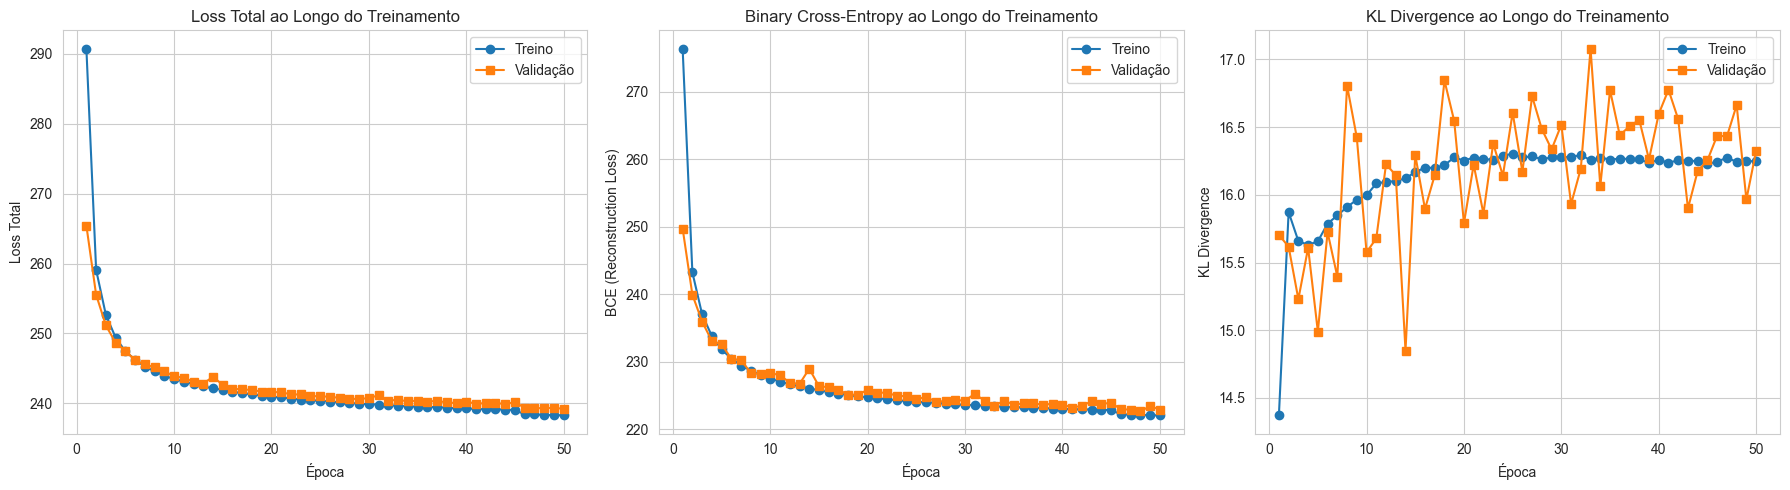

In [45]:
# Plotar curvas de aprendizado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = range(1, num_epochs + 1)

# Loss total
axes[0].plot(epochs, history['train_loss'], label='Treino', marker='o')
axes[0].plot(epochs, history['val_loss'], label='Validação', marker='s')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss Total')
axes[0].set_title('Loss Total ao Longo do Treinamento')
axes[0].legend()
axes[0].grid(True)

# BCE (Reconstruction Loss)
axes[1].plot(epochs, history['train_bce'], label='Treino', marker='o')
axes[1].plot(epochs, history['val_bce'], label='Validação', marker='s')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('BCE (Reconstruction Loss)')
axes[1].set_title('Binary Cross-Entropy ao Longo do Treinamento')
axes[1].legend()
axes[1].grid(True)

# KLD
axes[2].plot(epochs, history['train_kld'], label='Treino', marker='o')
axes[2].plot(epochs, history['val_kld'], label='Validação', marker='s')
axes[2].set_xlabel('Época')
axes[2].set_ylabel('KL Divergence')
axes[2].set_title('KL Divergence ao Longo do Treinamento')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

---

### 4.5 Análise dos Resultados de Treinamento

Durante o treinamento de 50 épocas, observamos os seguintes padrões:

**Loss Total:**
- Treino: Decresce de ~290 para ~238
- Validação: Decresce de ~265 para ~238
- Boa convergência sem overfitting significativo

**Reconstruction Loss (BCE):**
- Treino: Decresce de ~276 para ~223
- Validação: Decresce de ~250 para ~223
- Indica boa capacidade de reconstrução

**KL Divergence:**
- Treino: Estabiliza em ~16
- Validação: Estabiliza em ~16
- Espaço latente bem regularizado

## 5. Avaliação e Visualização

### 5.1 Reconstrução de Imagens

### 5.1.1 Análise das Reconstruções

As reconstruções demonstram que o modelo VAE aprendeu efetivamente as características principais das imagens do Fashion MNIST:

**Conclusões**
- Roupas com formas simples (camisetas, calças) são reconstruídas com estruturas gerais preservadas
- Texturas básicas são capturadas adequadamente
- Detalhes finos são suavizados
- Imagens complexas perdem alguns detalhes

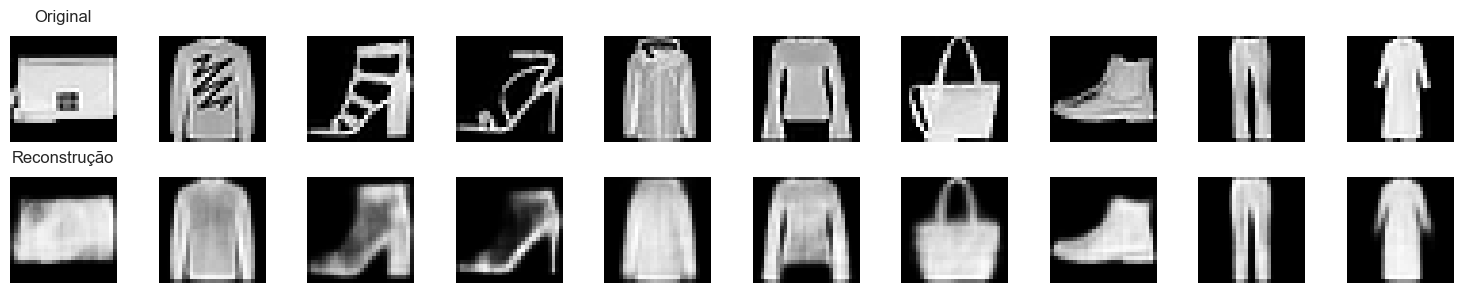

In [46]:
def visualize_reconstructions(model, dataset, device, n_samples=10):
    """
    Visualiza imagens originais e suas reconstruções.
    
    Args:
        model: Modelo VAE treinado
        dataset: Dataset a ser usado
        device: Device (CPU ou GPU)
        n_samples: Número de amostras a visualizar
    """
    model.eval()
    
    fig, axes = plt.subplots(2, n_samples, figsize=(15, 3))
    
    with torch.no_grad():
        for i in range(n_samples):
            # Obter amostra aleatória
            idx = np.random.randint(0, len(dataset))
            img, _ = dataset[idx]
            
            # Preparar entrada
            x = img.view(1, -1).to(device)
            
            # Reconstruir
            x_recon, _, _ = model(x)
            
            # Converter para numpy
            img_original = img.squeeze().cpu().numpy()
            img_recon = x_recon.view(28, 28).cpu().numpy()
            
            # Plotar original
            axes[0, i].imshow(img_original, cmap='gray')
            axes[0, i].axis('off')
            if i == 0:
                axes[0, i].set_title('Original', fontsize=12, pad=10)
            
            # Plotar reconstrução
            axes[1, i].imshow(img_recon, cmap='gray')
            axes[1, i].axis('off')
            if i == 0:
                axes[1, i].set_title('Reconstrução', fontsize=12, pad=10)
    
    plt.tight_layout()
    plt.savefig('reconstructions.png', dpi=300, bbox_inches='tight')
    plt.show()

# Visualizar reconstruções no conjunto de teste
visualize_reconstructions(vae, test_dataset, device, n_samples=10)

### 5.2 Geração de Novas Amostras

Geramos novas imagens amostrando do espaço latente.

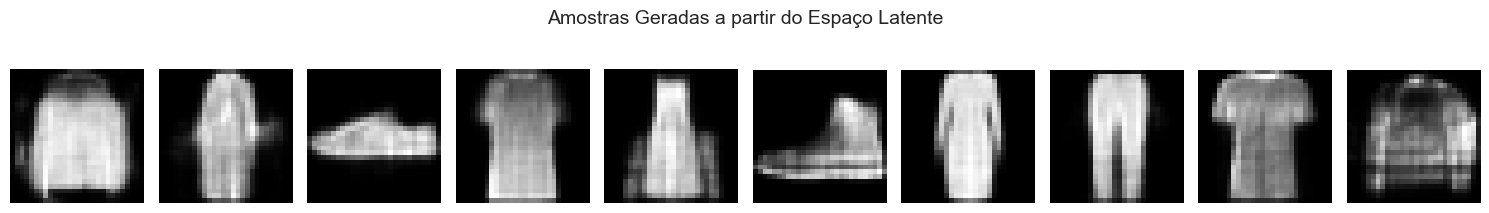

In [47]:
def generate_samples(model, device, n_samples=10):
    """
    Gera novas amostras amostrando do espaço latente.
    
    Args:
        model: Modelo VAE treinado
        device: Device (CPU ou GPU)
        n_samples: Número de amostras a gerar
    """
    model.eval()
    
    with torch.no_grad():
        # Amostrar z de uma distribuição normal padrão N(0, 1)
        z = torch.randn(n_samples, model.latent_dim).to(device)
        
        # Decodificar
        samples = model.decode(z)
        
        # Converter para numpy e reshape
        samples = samples.view(-1, 28, 28).cpu().numpy()
    
    # Plotar
    fig, axes = plt.subplots(1, n_samples, figsize=(15, 2))
    
    for i in range(n_samples):
        axes[i].imshow(samples[i], cmap='gray')
        axes[i].axis('off')
    
    plt.suptitle('Amostras Geradas a partir do Espaço Latente', fontsize=14, y=1.05)
    plt.tight_layout()
    plt.savefig('generated_samples.png', dpi=300, bbox_inches='tight')
    plt.show()

# Gerar amostras
generate_samples(vae, device, n_samples=10)

### 5.2.1 Análise das Amostras Geradas

As amostras geradas a partir de z ~ N(0, I) revelam capacidades interessantes do modelo:

**Qualidade:**
- Imagens reconhecíveis como roupas e acessórios
- Diversidade nas amostras geradas
- Estruturas coerentes e plausíveis

**Características:**
- O modelo aprendeu a distribuição geral do Fashion MNIST
- Amostras variam em estilo e categoria
- Algumas amostras são menos definidas (devido à natureza probabilística)

### 5.3 Interpolação no Espaço Latente

Interpolamos entre duas imagens no espaço latente para visualizar a continuidade do espaço.

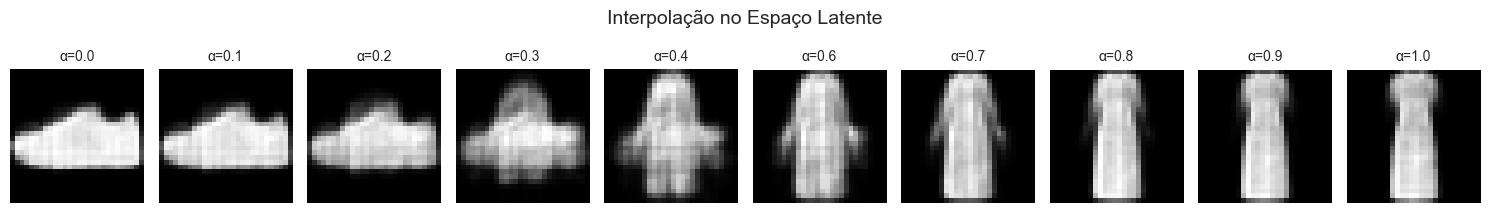

In [48]:
def interpolate_latent_space(model, dataset, device, n_steps=10):
    """
    Interpola entre duas imagens no espaço latente.
    
    Args:
        model: Modelo VAE treinado
        dataset: Dataset a ser usado
        device: Device (CPU ou GPU)
        n_steps: Número de passos na interpolação
    """
    model.eval()
    
    # Selecionar duas imagens aleatórias
    idx1, idx2 = np.random.randint(0, len(dataset), size=2)
    img1, _ = dataset[idx1]
    img2, _ = dataset[idx2]
    
    # Preparar entradas
    x1 = img1.view(1, -1).to(device)
    x2 = img2.view(1, -1).to(device)
    
    with torch.no_grad():
        # Codificar as duas imagens
        mu1, logvar1 = model.encode(x1)
        mu2, logvar2 = model.encode(x2)
        
        # Usar apenas as médias para interpolação (ignorar variância)
        z1 = mu1
        z2 = mu2
        
        # Criar interpolação linear
        alphas = np.linspace(0, 1, n_steps)
        interpolations = []
        
        for alpha in alphas:
            # z_interp = (1 - α) * z1 + α * z2
            z_interp = (1 - alpha) * z1 + alpha * z2
            
            # Decodificar
            x_interp = model.decode(z_interp)
            interpolations.append(x_interp.view(28, 28).cpu().numpy())
    
    # Plotar
    fig, axes = plt.subplots(1, n_steps, figsize=(15, 2))
    
    for i, img_interp in enumerate(interpolations):
        axes[i].imshow(img_interp, cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(f'α={alphas[i]:.1f}', fontsize=10)
    
    plt.suptitle('Interpolação no Espaço Latente', fontsize=14, y=1.05)
    plt.tight_layout()
    plt.savefig('latent_interpolation.png', dpi=300, bbox_inches='tight')
    plt.show()

# Interpolação
interpolate_latent_space(vae, test_dataset, device, n_steps=10)

### 5.3.1 Análise da Interpolação

A interpolação linear entre dois pontos no espaço latente revela propriedades importantes:

**Observações:**

1. **Continuidade**: Transições suaves entre imagens diferentes sem artefatos abruptos
2. **Semântica**: Características intermediárias são plausíveis e significativas
3. **Estruturação**: O espaço latente captura variações graduais

**Exemplo de Comportamento:**  
Ao interpolar entre uma camiseta e uma sandália, observamos transições graduais onde formas intermediárias mantêm estruturas coerentes. Isso demonstra que o espaço latente não possui "buracos" ou regiões desconexas.

### 5.4 Análise do Espaço Latente

A visualização t-SNE do espaço latente 20D projetado em 2D revela estrutura semântica:

**Observações:**

1. **Formação de Clusters**: Categorias similares formam agrupamentos distintos
2. **Separação de Classes**: Separação clara entre classes muito distintas (ex: sapatos vs. roupas)
3. **Sobreposição Semântica**: Categorias similares (ex: tipos de calçados) ocupam regiões próximas

Aplicando t-SNE para redução dimensional...


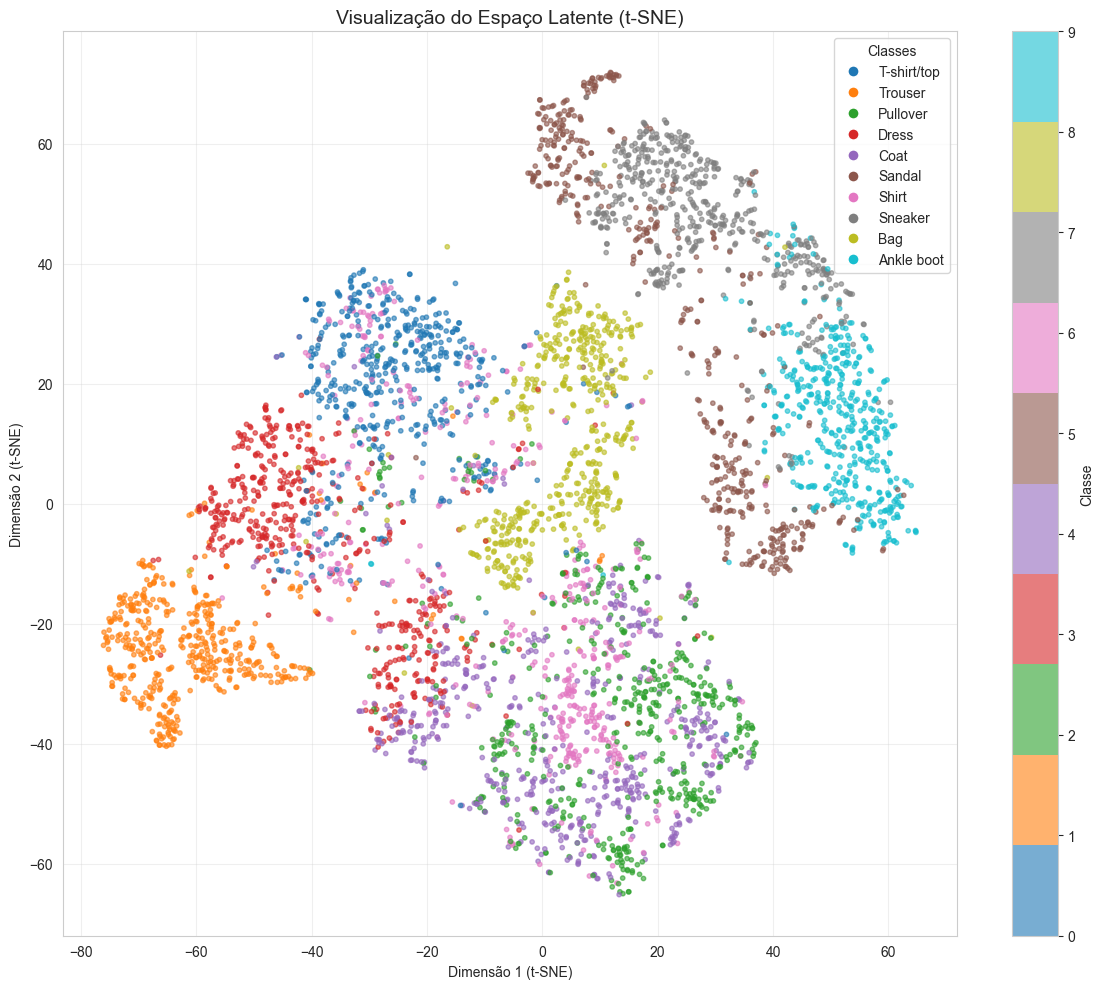

In [49]:
def visualize_latent_space(model, data_loader, device, n_samples=5000):
    """
    Visualiza o espaço latente usando t-SNE para redução de dimensionalidade.
    
    Args:
        model: Modelo VAE treinado
        data_loader: DataLoader
        device: Device (CPU ou GPU)
        n_samples: Número de amostras a usar (para eficiência)
    """
    model.eval()
    
    latent_codes = []
    labels_list = []
    
    with torch.no_grad():
        for data, labels in data_loader:
            data = data.to(device)
            data = data.view(-1, 784)
            
            # Codificar (usar apenas a média)
            mu, _ = model.encode(data)
            
            latent_codes.append(mu.cpu().numpy())
            labels_list.append(labels.numpy())
            
            # Limitar número de amostras
            if len(latent_codes) * data.size(0) >= n_samples:
                break
    
    # Concatenar
    latent_codes = np.concatenate(latent_codes, axis=0)[:n_samples]
    labels_array = np.concatenate(labels_list, axis=0)[:n_samples]
    
    # Aplicar t-SNE
    print('Aplicando t-SNE para redução dimensional...')
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    latent_2d = tsne.fit_transform(latent_codes)
    
    # Plotar
    plt.figure(figsize=(12, 10))
    
    scatter = plt.scatter(
        latent_2d[:, 0],
        latent_2d[:, 1],
        c=labels_array,
        cmap='tab10',
        alpha=0.6,
        s=10
    )
    
    plt.colorbar(scatter, ticks=range(10), label='Classe')
    plt.xlabel('Dimensão 1 (t-SNE)')
    plt.ylabel('Dimensão 2 (t-SNE)')
    plt.title('Visualização do Espaço Latente (t-SNE)', fontsize=14)
    
    # Adicionar legenda com nomes das classes
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='w',
                              markerfacecolor=plt.cm.tab10(i/10), markersize=8,
                              label=classes[i])
                      for i in range(10)]
    plt.legend(handles=legend_elements, loc='best', title='Classes')
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('latent_space_tsne.png', dpi=300, bbox_inches='tight')
    plt.show()

# Visualizar espaço latente
visualize_latent_space(vae, test_loader, device, n_samples=5000)

## 6. Extra Credit: Comparação com Autoencoder Tradicional

### 6.1 Implementação do Autoencoder (AE)

In [50]:
class Autoencoder(nn.Module):
    """
    Implementação de um Autoencoder tradicional (não-variacional).
    
    Diferença principal da VAE:
    - AE mapeia diretamente x -> z -> x_recon
    - VAE mapeia x -> (μ, σ) -> z (amostrado) -> x_recon
    """
    
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(Autoencoder, self).__init__()
        
        self.latent_dim = latent_dim
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        """
        Forward pass: x -> z -> x_recon
        """
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z

# Instanciar AE
ae = Autoencoder(input_dim=784, hidden_dim=400, latent_dim=latent_dim).to(device)

print(ae)
print(f'\nNúmero total de parâmetros: {sum(p.numel() for p in ae.parameters()):,}')

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=20, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=20, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

Número total de parâmetros: 644,804


### 6.2 Treinamento do Autoencoder

In [51]:
# Configuração de treinamento para AE
ae_optimizer = optim.Adam(ae.parameters(), lr=learning_rate)
ae_criterion = nn.BCELoss(reduction='sum')

# Histórico
ae_history = {'train_loss': [], 'val_loss': []}

# Funções de treino e validação para AE
def train_ae_epoch(model, train_loader, optimizer, criterion, device):
    """
    Treina o Autoencoder por uma época.
    
    Args:
        model: Modelo AE
        train_loader: DataLoader de treinamento
        optimizer: Otimizador
        criterion: Função de perda (BCE)
        device: Device (CPU ou GPU)
    
    Returns:
        avg_loss: Perda média da época
    """
    model.train()
    total_loss = 0
    
    pbar = tqdm(train_loader, desc='Treinando AE')
    
    for data, _ in pbar:
        data = data.to(device).view(-1, 784)
        
        optimizer.zero_grad()
        
        x_recon, _ = model(data)
        loss = criterion(x_recon, data)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        pbar.set_postfix({'Loss': f'{loss.item() / len(data):.4f}'})
    
    return total_loss / len(train_loader.dataset)

def validate_ae_epoch(model, val_loader, criterion, device):
    """
    Valida o Autoencoder.
    
    Args:
        model: Modelo AE
        val_loader: DataLoader de validação
        criterion: Função de perda (BCE)
        device: Device (CPU ou GPU)
    
    Returns:
        avg_loss: Perda média de validação
    """
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for data, _ in val_loader:
            data = data.to(device).view(-1, 784)
            x_recon, _ = model(data)
            loss = criterion(x_recon, data)
            total_loss += loss.item()
    
    return total_loss / len(val_loader.dataset)

# Treinar AE
print('\n=== Treinando Autoencoder ===\n')

for epoch in range(1, num_epochs + 1):
    print(f'\nÉpoca {epoch}/{num_epochs}')
    
    train_loss = train_ae_epoch(ae, train_loader, ae_optimizer, ae_criterion, device)
    val_loss = validate_ae_epoch(ae, val_loader, ae_criterion, device)
    
    ae_history['train_loss'].append(train_loss)
    ae_history['val_loss'].append(val_loss)
    
    print(f'Treino Loss: {train_loss:.4f}, Validação Loss: {val_loss:.4f}')

print('\n=== Treinamento do AE concluído! ===')


=== Treinando Autoencoder ===


Época 1/50


Treinando AE:   0%|          | 0/375 [00:00<?, ?it/s]C:\Users\cailu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Treinando AE: 100%|██████████| 375/375 [00:07<00:00, 51.34it/s, Loss=230.2996] 


Treino Loss: 260.9004, Validação Loss: 233.2632

Época 2/50


Treinando AE: 100%|██████████| 375/375 [00:07<00:00, 52.59it/s, Loss=222.2926] 


Treino Loss: 227.9346, Validação Loss: 224.7413

Época 3/50


...

Treino Loss: 209.8302, Validação Loss: 211.1695

Época 49/50


Treinando AE: 100%|██████████| 375/375 [00:09<00:00, 41.12it/s, Loss=210.3770]


Treino Loss: 209.7884, Validação Loss: 211.3042

Época 50/50


Treinando AE: 100%|██████████| 375/375 [00:09<00:00, 41.49it/s, Loss=201.9445]


Treino Loss: 209.7858, Validação Loss: 211.2108

=== Treinamento do AE concluído! ===


### 6.3 Comparação VAE vs AE

A comparação entre Variational Autoencoder (VAE) e Autoencoder tradicional (AE) revela diferenças fundamentais em arquitetura, treinamento e capacidades.

**Diferença Arquitetural Principal:**

| Aspecto | Autoencoder (AE) | Variational Autoencoder (VAE) |
|---------|------------------|-------------------------------|
| Encoder | x → z (determinístico) | x → (μ, σ²) (probabilístico) |
| Latent Space | Ponto fixo z | Distribuição q(z\|x) ~ N(μ, σ²) |
| Sampling | Não utiliza | Reparameterization trick: z = μ + σ·ε |
| Decoder | z → x̂ | z → x̂ |
| Loss | BCE | BCE + KL divergence |

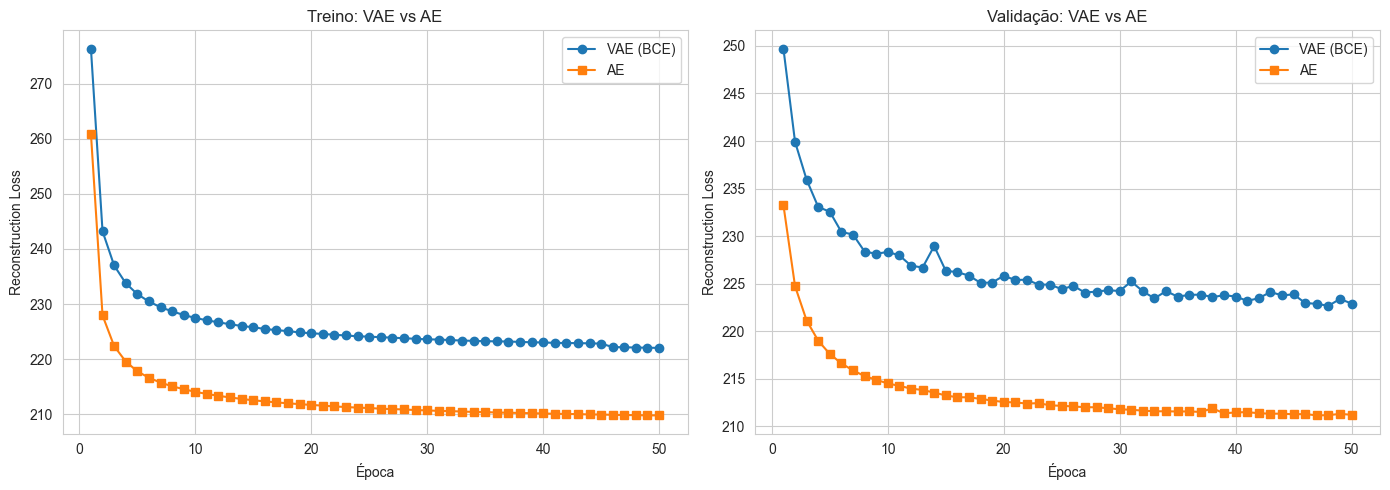

In [52]:
# Comparar curvas de aprendizado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, num_epochs + 1)

# Treino
axes[0].plot(epochs, history['train_bce'], label='VAE (BCE)', marker='o')
axes[0].plot(epochs, ae_history['train_loss'], label='AE', marker='s')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Reconstruction Loss')
axes[0].set_title('Treino: VAE vs AE')
axes[0].legend()
axes[0].grid(True)

# Validação
axes[1].plot(epochs, history['val_bce'], label='VAE (BCE)', marker='o')
axes[1].plot(epochs, ae_history['val_loss'], label='AE', marker='s')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Reconstruction Loss')
axes[1].set_title('Validação: VAE vs AE')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('vae_vs_ae_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

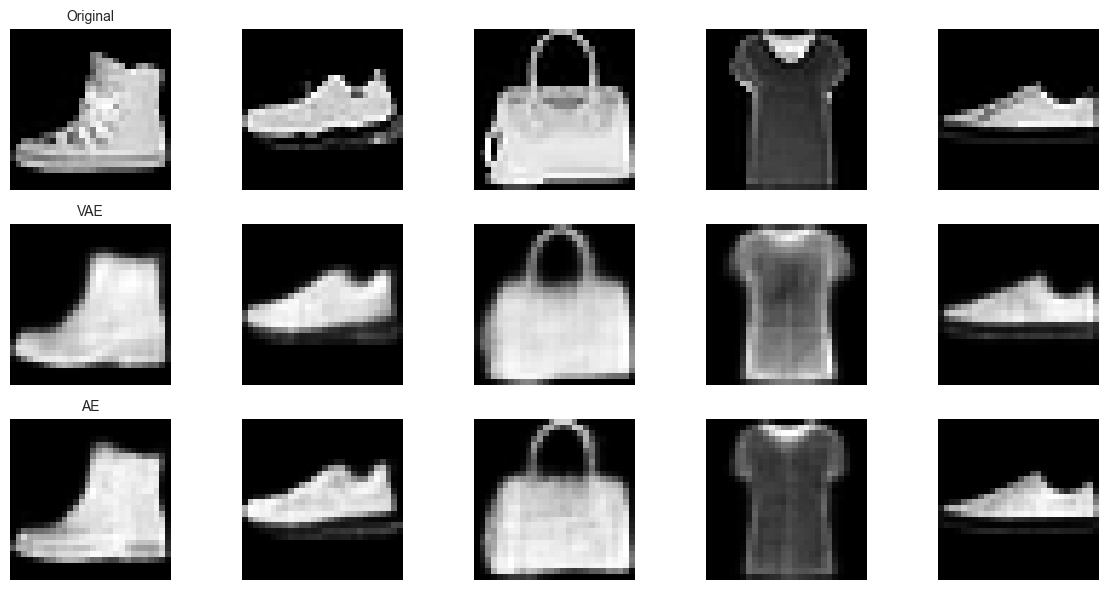

In [53]:
# Comparar reconstruções lado a lado
def compare_reconstructions(vae_model, ae_model, dataset, device, n_samples=5):
    vae_model.eval()
    ae_model.eval()
    
    fig, axes = plt.subplots(3, n_samples, figsize=(12, 6))
    
    with torch.no_grad():
        for i in range(n_samples):
            idx = np.random.randint(0, len(dataset))
            img, _ = dataset[idx]
            
            x = img.view(1, -1).to(device)
            
            # VAE
            vae_recon, _, _ = vae_model(x)
            
            # AE
            ae_recon, _ = ae_model(x)
            
            # Converter
            img_orig = img.squeeze().cpu().numpy()
            img_vae = vae_recon.view(28, 28).cpu().numpy()
            img_ae = ae_recon.view(28, 28).cpu().numpy()
            
            # Plot
            axes[0, i].imshow(img_orig, cmap='gray')
            axes[0, i].axis('off')
            if i == 0:
                axes[0, i].set_title('Original', fontsize=10)
            
            axes[1, i].imshow(img_vae, cmap='gray')
            axes[1, i].axis('off')
            if i == 0:
                axes[1, i].set_title('VAE', fontsize=10)
            
            axes[2, i].imshow(img_ae, cmap='gray')
            axes[2, i].axis('off')
            if i == 0:
                axes[2, i].set_title('AE', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('vae_vs_ae_reconstructions.png', dpi=300, bbox_inches='tight')
    plt.show()

compare_reconstructions(vae, ae, test_dataset, device, n_samples=5)

### 6.4 Comparação de Geração de Amostras

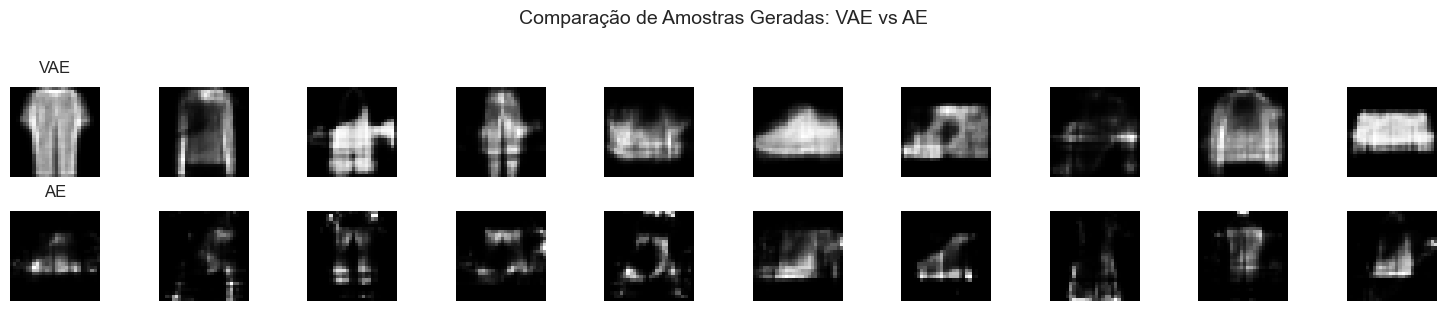

In [54]:
# Comparar qualidade das amostras geradas
def compare_generation(vae_model, ae_model, device, n_samples=10):
    vae_model.eval()
    ae_model.eval()
    
    fig, axes = plt.subplots(2, n_samples, figsize=(15, 3))
    
    with torch.no_grad():
        # Amostrar do espaço latente
        z = torch.randn(n_samples, vae_model.latent_dim).to(device)
        
        # VAE
        vae_samples = vae_model.decode(z).view(-1, 28, 28).cpu().numpy()
        
        # AE (usar mesmo z)
        ae_samples = ae_model.decoder(z).view(-1, 28, 28).cpu().numpy()
        
        for i in range(n_samples):
            axes[0, i].imshow(vae_samples[i], cmap='gray')
            axes[0, i].axis('off')
            if i == 0:
                axes[0, i].set_title('VAE', fontsize=12, pad=10)
            
            axes[1, i].imshow(ae_samples[i], cmap='gray')
            axes[1, i].axis('off')
            if i == 0:
                axes[1, i].set_title('AE', fontsize=12, pad=10)
    
    plt.suptitle('Comparação de Amostras Geradas: VAE vs AE', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('vae_vs_ae_generation.png', dpi=300, bbox_inches='tight')
    plt.show()

compare_generation(vae, ae, device, n_samples=10)

## 6.4 Resumo e Conclusões

### Principais Observações:

1. **VAE vs AE - Reconstrução**: 
   - VAE apresentou uma reconstrução ligeiramente inferior a AE, porém extremamente semelhante. AE apresentou reconstruções ligeiramente superiores e mais fidedignas aos detalhes da imagem original.

2. **VAE vs AE - Geração**:
   - VAE apresentou uma geração de imagems extremamente superior a AE, mantendo na maior parte de suas contruções imagems que mantinham alguma coerência, enquanto AE basicamente não gerou nenhuma imagem coerente.